# Ensambles

### Bootstrap

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

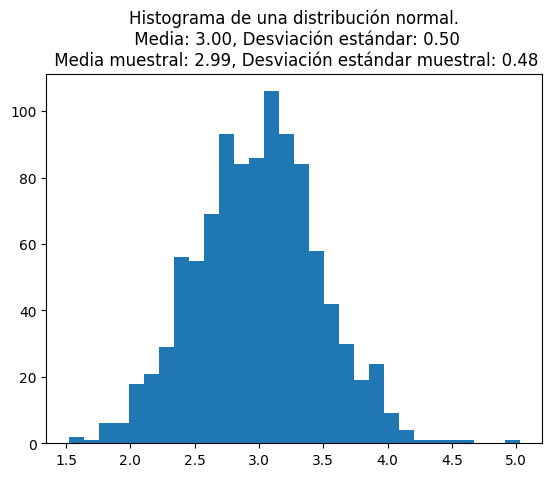

In [2]:
n_muestras = 1000
valor_medio = 3
desviacion_estandar = 0.5
muestras = np.random.normal(valor_medio, desviacion_estandar, n_muestras)

plt.hist(muestras, bins=30)
title = 'Histograma de una distribución normal.'
title += f'\n Media: {valor_medio:.2f}, Desviación estándar: {desviacion_estandar:.2f}'
title += f'\n Media muestral: {muestras.mean():.2f}, Desviación estándar muestral: {muestras.std():.2f}'

plt.title(title)
plt.show()

In [3]:
np.random.seed(42)
df_resultados = pd.DataFrame(columns=['media_muestral'])
N_repeticiones = 1000
n_muestras = 1000

for i in range(N_repeticiones):
    muestras = np.random.normal(valor_medio, desviacion_estandar, n_muestras)
    df_resultados.loc[i] = muestras.mean()


La teoría dice que la distribución de las medias así obtenidas sigue la distribución normal, con media igual a la media de la población y desviación estándar igual a la desviación estándar de la población dividida por la raíz cuadrada del tamaño de la muestra.

$$ \bar{X} \sim N(\mu, \frac{\sigma}{\sqrt{n}}) $$

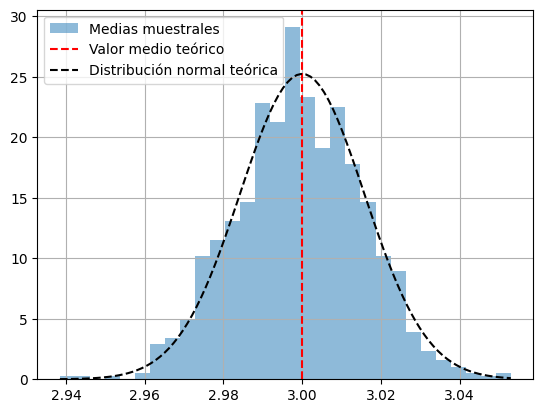

In [4]:
df_resultados.media_muestral.hist(bins=30, density=True, alpha=0.5, label = 'Medias muestrales')
plt.axvline(x=valor_medio, color='r', linestyle='--', label='Valor medio teórico')

x = np.linspace(df_resultados.media_muestral.min(),
                df_resultados.media_muestral.max(), 100)
y = norm.pdf(x, valor_medio, desviacion_estandar/np.sqrt(n_muestras))

plt.plot(x, y, 'k--', label='Distribución normal teórica')
plt.legend()

In [5]:
np.random.seed(42)
muestras = np.random.normal(valor_medio, desviacion_estandar, n_muestras)

for i in range(N_repeticiones):
    muestras_bootstrap = np.random.choice(muestras, n_muestras, replace=True)
    df_resultados.loc[i,'media_bootstrap'] = muestras_bootstrap.mean()
    # break

Media muestral: 3.00 +- 0.02
Media bootstrap: 3.01 +- 0.02


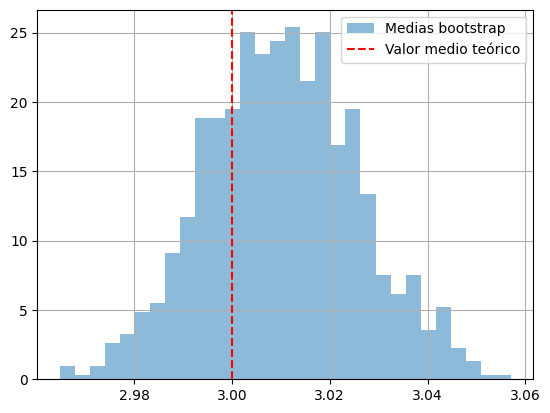

In [7]:
#df_resultados.media_muestral.hist(bins=30, density=True, alpha=0.5, label='Medias muestrales')
df_resultados.media_bootstrap.hist(bins=30, density=True, alpha=0.5, label='Medias bootstrap')
plt.axvline(x=valor_medio, color='r', linestyle='--', label='Valor medio teórico')
#plt.axvline(x=df_resultados.media_bootstrap.mean(), color='g', linestyle='--', label='Valor medio bootstrap')

### plot theorical distribution
#from scipy.stats import norm
#x = np.linspace(df_resultados.media_muestral.min(),
#                     df_resultados.media_muestral.max(), 100)
#y = norm.pdf(x, valor_medio, desviacion_estandar/np.sqrt(n_muestras))

#plt.plot(x, y, 'k--', label='Distribución normal teórica')
plt.legend()

print(f'Media muestral: {df_resultados.media_muestral.mean():.2f} +- {df_resultados.media_muestral.std():.2f}')
print(f'Media bootstrap: {df_resultados.media_bootstrap.mean():.2f} +- {df_resultados.media_bootstrap.std():.2f}')

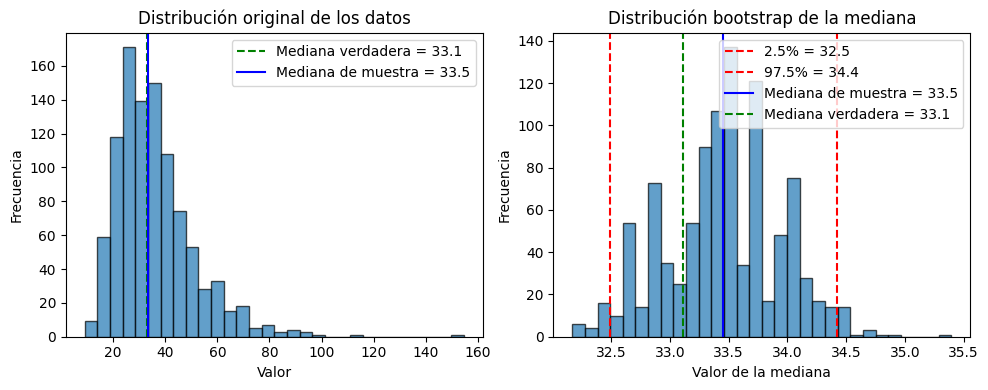

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la distribución log-normal
media_log = 3.5
sigma_log = 0.4
tamano_muestra = 1000

# Semilla para reproducibilidad
np.random.seed(42)

# Generar datos desde la distribución log-normal
datos = np.random.lognormal(mean=media_log, sigma=sigma_log, size=tamano_muestra)

# Mediana verdadera de la distribución
mediana_verdadera = np.exp(media_log)

# Bootstrap: calcular medianas de muestras con reemplazo
n_bootstrap = 1000
medianas_bootstrap = []
for _ in range(n_bootstrap):
    muestra = np.random.choice(datos, size=len(datos), replace=True)
    medianas_bootstrap.append(np.median(muestra))

# Calcular intervalo de confianza al 95%
limite_inferior = np.percentile(medianas_bootstrap, 2.5)
limite_superior = np.percentile(medianas_bootstrap, 97.5)
mediana_muestra = np.median(datos)

# Graficar
plt.figure(figsize=(10, 4))

# Distribución original de los datos
plt.subplot(1, 2, 1)
plt.hist(datos, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(mediana_verdadera, color='green', linestyle='--', label=f'Mediana verdadera = {mediana_verdadera:.1f}')
plt.axvline(mediana_muestra, color='blue', linestyle='-', label=f'Mediana de muestra = {mediana_muestra:.1f}')
plt.title('Distribución original de los datos')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.legend()

# Distribución bootstrap de la mediana
plt.subplot(1, 2, 2)
plt.hist(medianas_bootstrap, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(limite_inferior, color='red', linestyle='--', label=f'2.5% = {limite_inferior:.1f}')
plt.axvline(limite_superior, color='red', linestyle='--', label=f'97.5% = {limite_superior:.1f}')
plt.axvline(mediana_muestra, color='blue', linestyle='-', label=f'Mediana de muestra = {mediana_muestra:.1f}')
plt.axvline(mediana_verdadera, color='green', linestyle='--', label=f'Mediana verdadera = {mediana_verdadera:.1f}')
plt.title('Distribución bootstrap de la mediana')
plt.xlabel('Valor de la mediana')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()


### Bagging - Bootstrap Aggregating

In [8]:
# Función que nos ayuda a graficar
# No hace falta que comprandan este bloque de código.
def visualize_classifier(model, X, y, ax=None, proba=False):
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(y, pd.Series):
        y = y.values
    ax = ax or plt.gca()

    colors_tab10 = plt.cm.tab10.colors

    for i, y_value in enumerate(reversed(np.unique(y))):
        ax.scatter(X[y==y_value, 0], X[y==y_value, 1], s=30,
                   zorder=3, alpha = 0.5, color = colors_tab10[i])

    ax.axis('tight')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    # ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    aux = pd.DataFrame(data=np.c_[xx.ravel(), yy.ravel()], columns=model.feature_names_in_)
    if proba:
        Z = model.predict_proba(aux)[:, 1].reshape(xx.shape)
    else:
        Z = model.predict(aux).reshape(xx.shape)


    # Create a color plot with the results
    Z = -Z + 1
    ax.pcolormesh(xx,yy,Z,cmap='bwr', vmin=0, vmax=1, alpha=0.2)

    ax.set(xlim=xlim, ylim=ylim)


In [10]:
# Cargar el dataset
data = pd.read_csv('penguins_size.csv')
data = data[data.sex != '.']
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)
data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


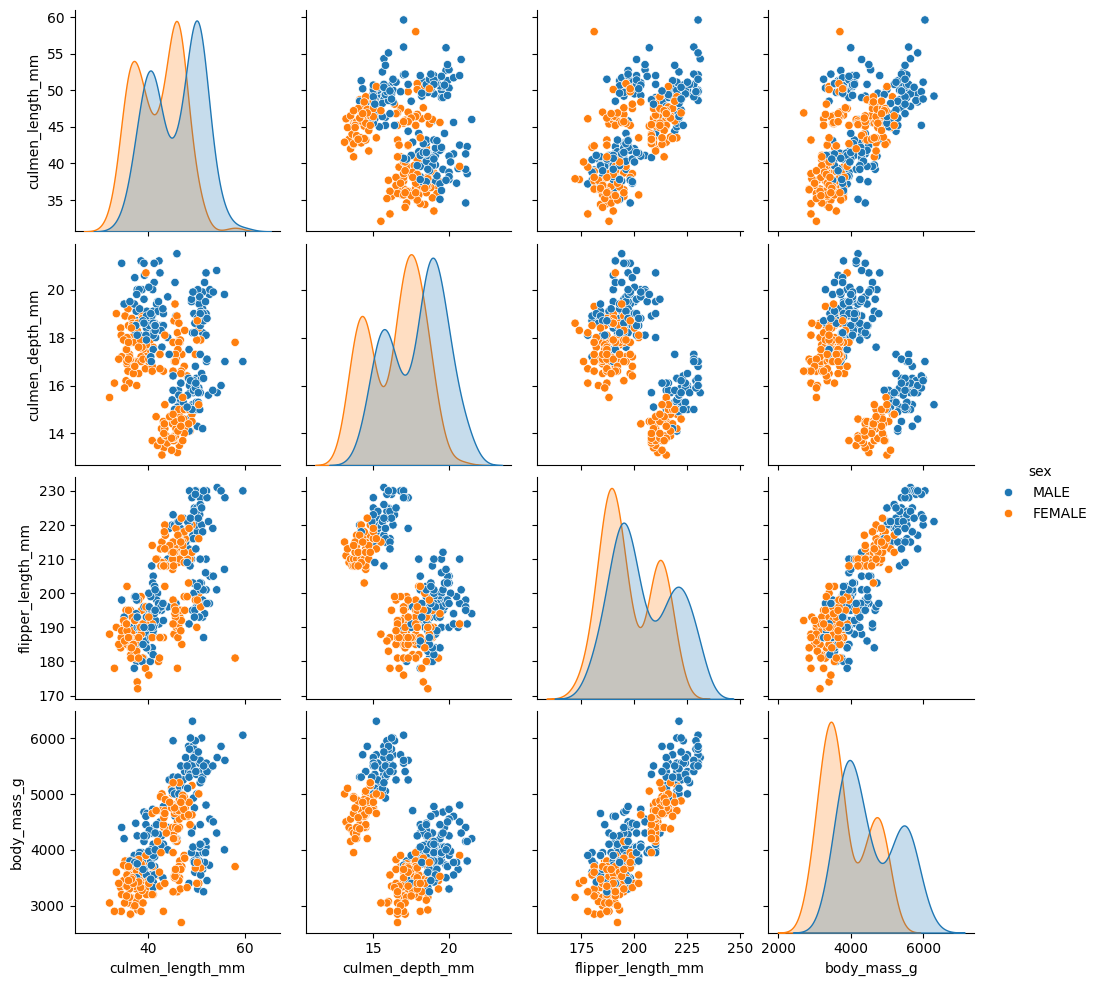

In [11]:
sns.pairplot(data, hue='sex')

In [12]:
# Separar características y etiqueta
X = data[['culmen_depth_mm', 'culmen_length_mm']]
y = data['sex']
y = y.map({'FEMALE': 0, 'MALE': 1})

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
np.random.seed(42)

### Modelo de referencia
clf = DecisionTreeClassifier(max_depth=None)
# clf = LogisticRegression(penalty=None)

clf.fit(X_train, y_train)

print(f"Train accuracy: {clf.score(X_train, y_train):.2f}")
print(f"Test accuracy: {clf.score(X_test, y_test):.2f}")

Train accuracy: 1.00
Test accuracy: 0.82


In [ ]:
# from sklearn.metrics import accuracy_score
# y_test_pred = clf.predict(X_test)
# accuracy_score(y_test, y_test_pred)

0.8208955223880597

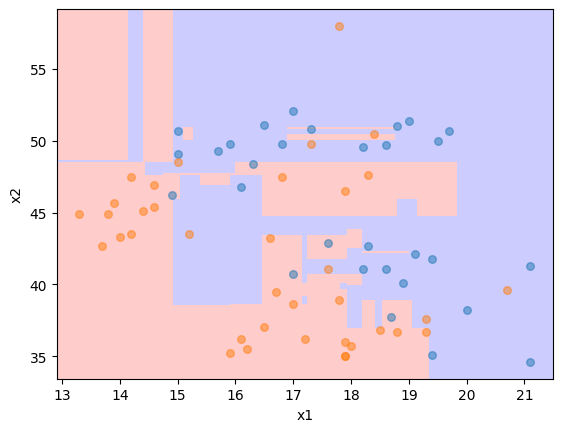

In [17]:
visualize_classifier(clf, X_test, y_test)

**Bagging**

In [18]:
len(X_train)

266

In [19]:
bagging_models = []
n_estimators = 100
np.random.seed(42)
for i in range(n_estimators):
    random_indices = np.random.choice(np.arange(len(X_train)), 100, replace=True)
    X_boot = X_train.iloc[random_indices]
    y_boot = y_train.iloc[random_indices]
    clf = DecisionTreeClassifier(max_depth=None)
    clf.fit(X_boot, y_boot)
    bagging_models.append(clf)


Evaluation on test

In [20]:
y_test_pred = np.zeros((X_test.shape[0], n_estimators))
y_test_pred_proba = np.zeros((X_test.shape[0], n_estimators))
for i, model in enumerate(bagging_models):
    y_test_pred[:, i] = model.predict(X_test)
    y_test_pred_proba[:, i] = model.predict_proba(X_test)[:, 1]

In [23]:
y_test_pred.shape, y_test.shape

((67, 100), (67,))

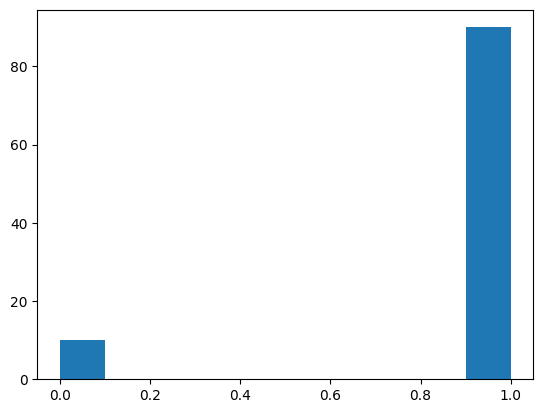

In [24]:
plt.hist(y_test_pred_proba[4, :]);

In [25]:
y_test_pred = (y_test_pred.mean(axis=1) > 0.5).astype(int)
# y_test_pred

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred)

0.8208955223880597

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

np.random.seed(42)
# clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None),
#                         n_estimators=100, n_jobs=-1)

clf = RandomForestClassifier(n_estimators=100,
                             n_jobs=-1,
                             max_features=None,
                            #  max_features='sqrt',
                             )
clf.fit(X_train, y_train)

y_test_pred = clf.predict(X_test)
accuracy_score(y_test, y_test_pred)

0.7611940298507462

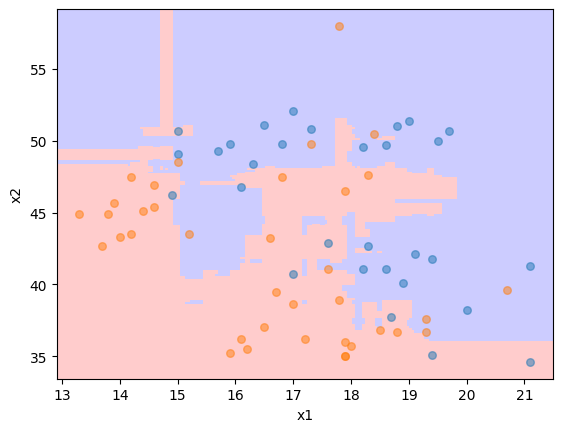

In [ ]:
visualize_classifier(clf, X_test, y_test)

### Boosting

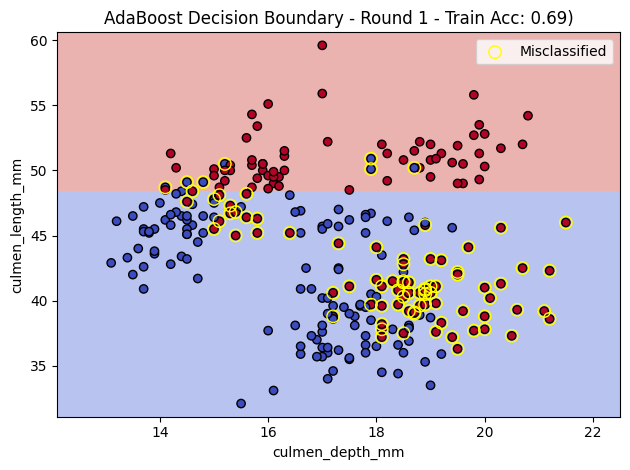

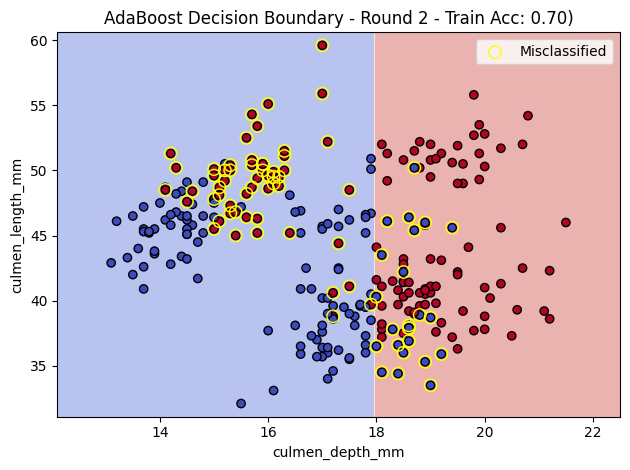

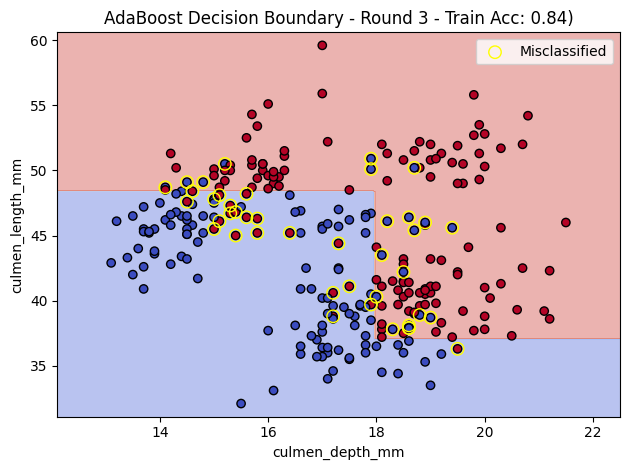

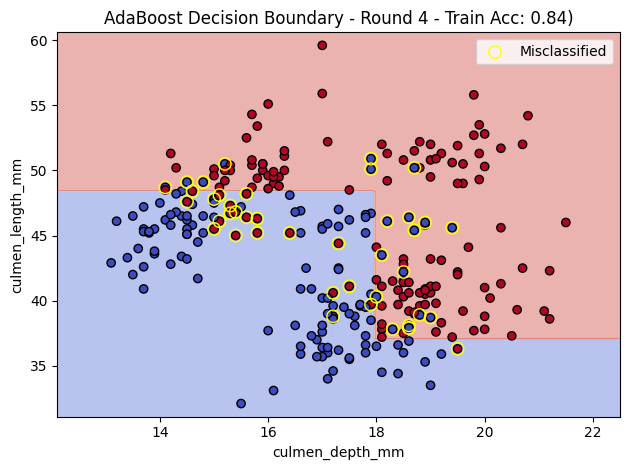

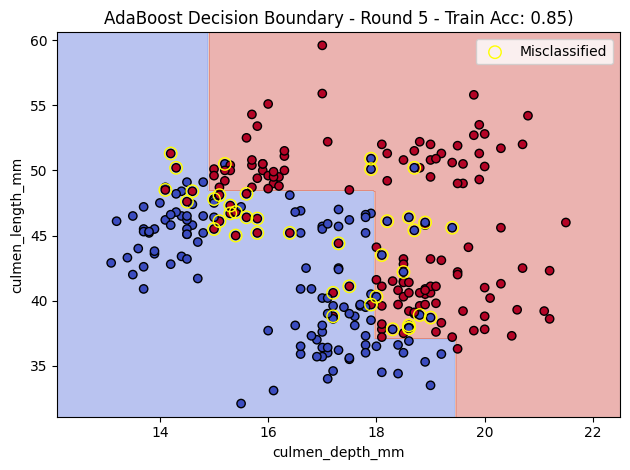

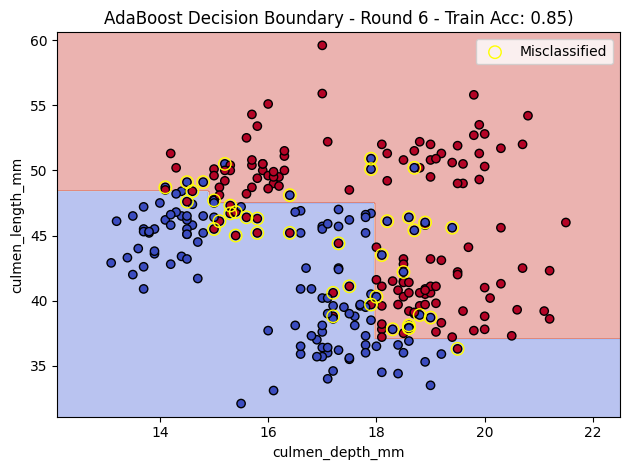

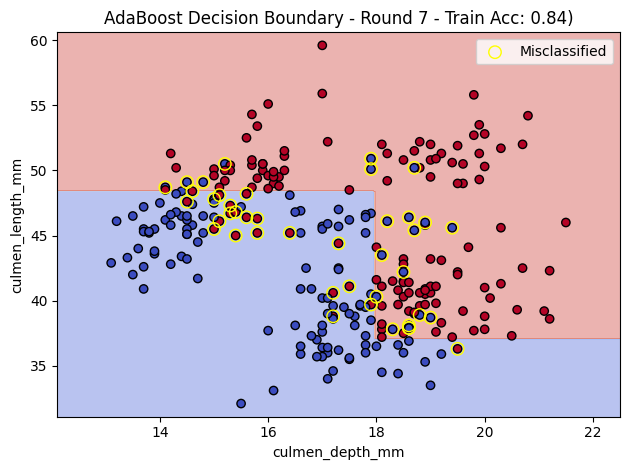

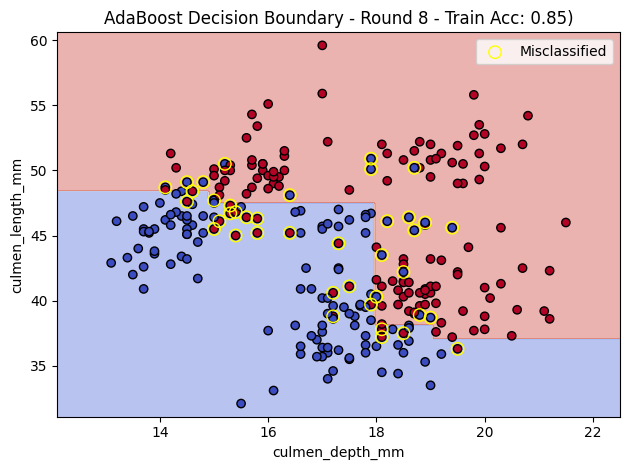

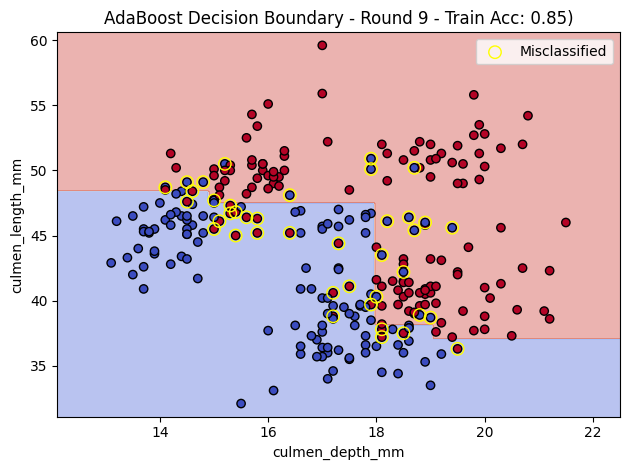

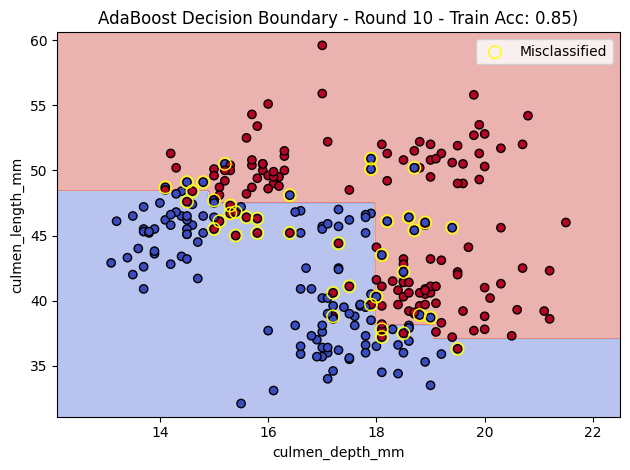

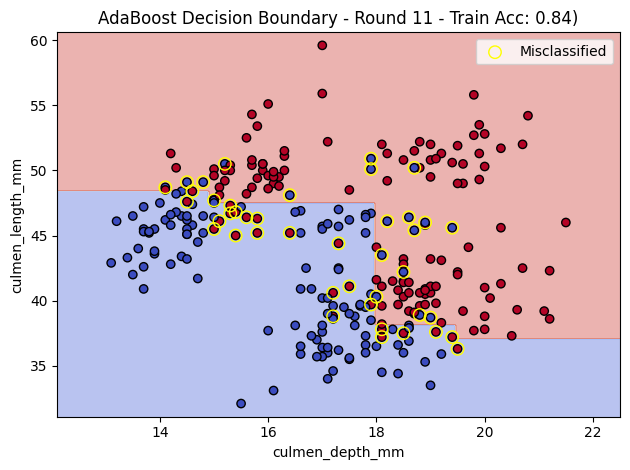

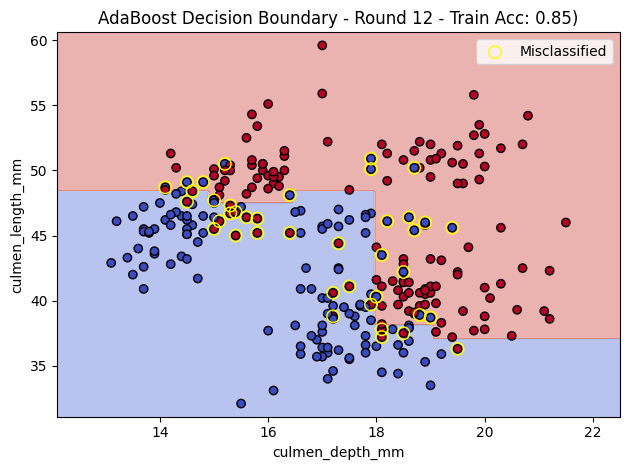

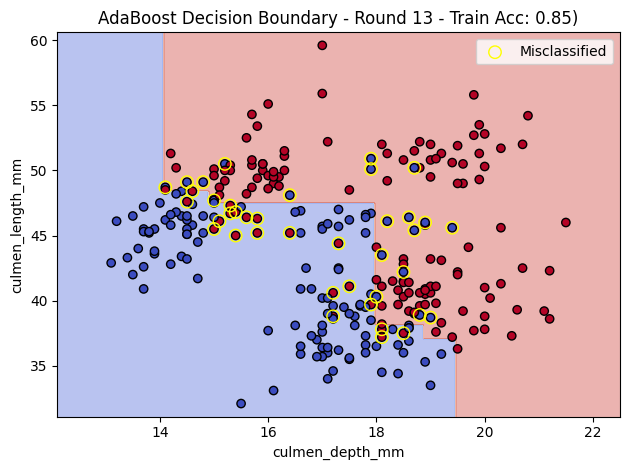

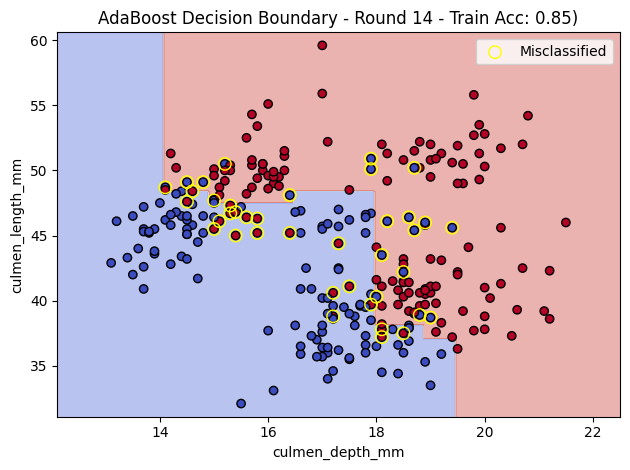

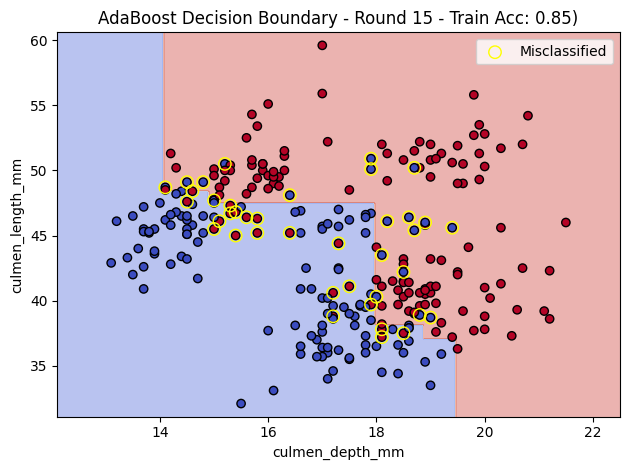

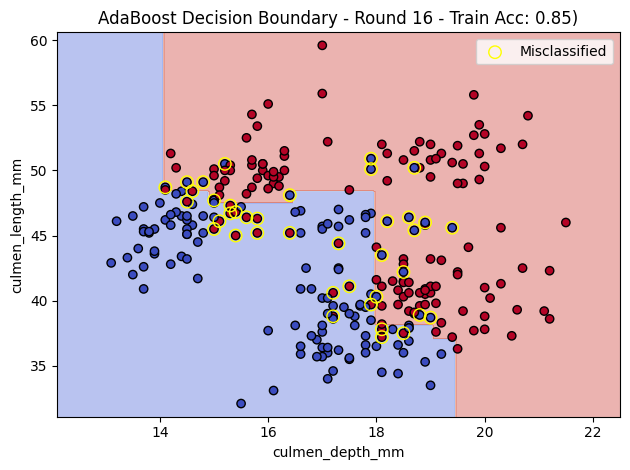

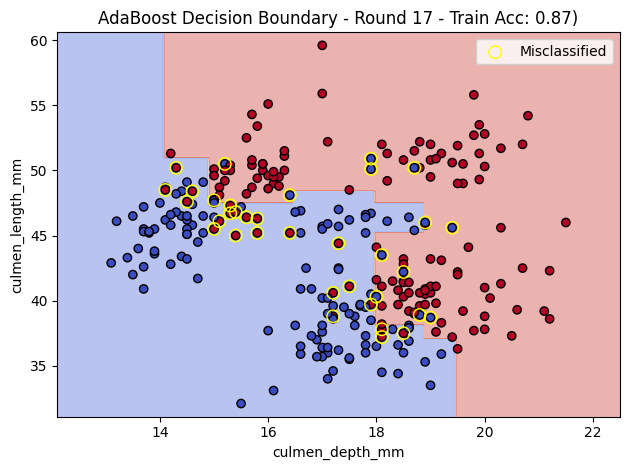

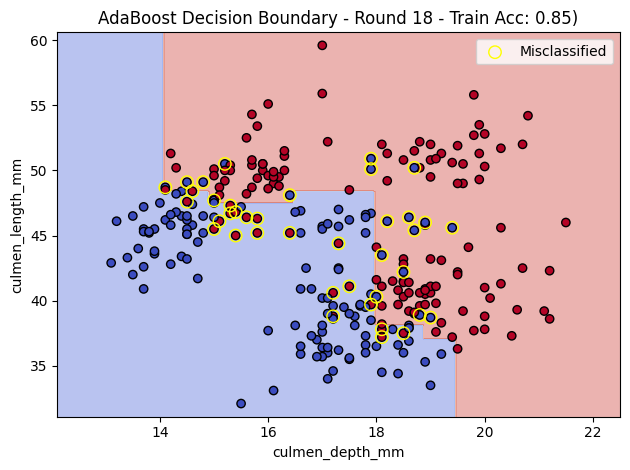

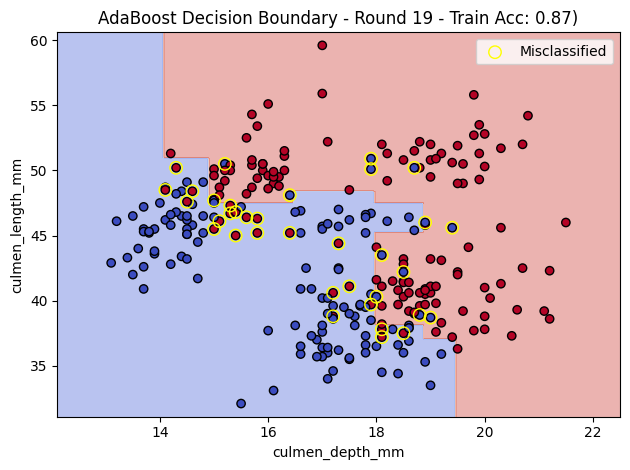

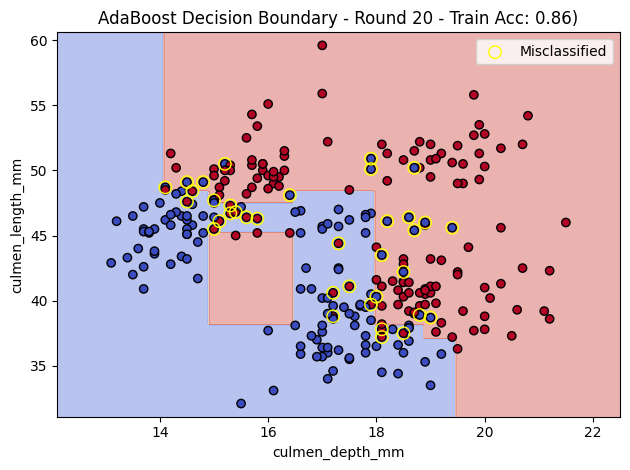

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Extract feature arrays
X_train_array = X_train.values
y_train_array = y_train.values

# Train AdaBoost
model = AdaBoostClassifier(n_estimators=20)
model.fit(X_train_array, y_train_array)

# Meshgrid for decision boundary
x_min, x_max = X_train_array[:, 0].min() - 1, X_train_array[:, 0].max() + 1
y_min, y_max = X_train_array[:, 1].min() - 1, X_train_array[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Plot each AdaBoost stage
for i, y_pred_train in enumerate(model.staged_predict(X_train_array), 1):
    incorrect = y_pred_train != y_train_array
    y_pred_grid = list(model.staged_predict(grid))[i - 1]
    Z = y_pred_grid.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X_train_array[:, 0], X_train_array[:, 1], c=y_train_array,
                cmap='coolwarm', edgecolors='k')
    plt.scatter(X_train_array[incorrect, 0], X_train_array[incorrect, 1],
                facecolors='none', edgecolors='yellow', s=80, label='Misclassified')
    acc = (y_pred_train == y_train_array).mean()
    plt.xlabel("culmen_depth_mm")
    plt.ylabel("culmen_length_mm")
    plt.title(f"AdaBoost Decision Boundary - Round {i} - Train Acc: {acc:.2f})")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [ ]:
from xgboost import XGBClassifier

# Train with many estimators
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=1,
)
model.fit(X_train, y_train)

# Full prediction
y_pred_full = model.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
print(f"Accuracy: {acc_full:.3f}")

Accuracy: 0.821


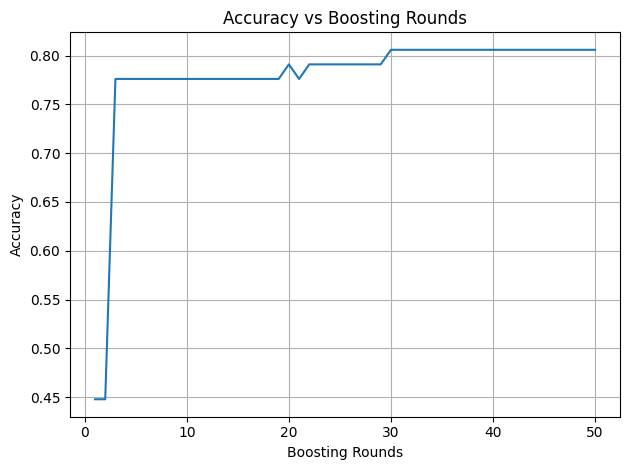

In [ ]:
# Accuracy vs Boosting Rounds
accuracies = []
for r in range(1, 51):
    y_pred = model.predict(X_test, iteration_range=(0, r))
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot
plt.plot(range(1, 51), accuracies)
plt.xlabel("Boosting Rounds")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Boosting Rounds")
plt.grid(True)
plt.tight_layout()
plt.show()